In [1]:
import numpy as np
from collections import defaultdict

# ==================== 1. 环境设置 ====================
# 4x4 网格世界，起点 S，终点 G，陷阱 H
# 动作: 0=上, 1=右, 2=下, 3=左
ACTIONS = [0, 1, 2, 3]
gamma = 0.9  # 折扣因子

# 环境布局 (0:普通, 1:终点G, -1:陷阱H)
# 状态编号 0-15
# 0 1 2 3
# 4 5 6 7
# 8 9 10 11
# 12 13 14 15

# 定义特殊状态
GOAL_STATE = 15
TRAP_STATE = 5  # 设5号为陷阱

# 动作影响：更新位置 (dx, dy)
# 状态 = row*4 + col
def take_action(state, action):
    if state == GOAL_STATE or state == TRAP_STATE:
        return state, 0  # 游戏结束，无奖励
    
    row, col = divmod(state, 4)
    if action == 0: row = max(0, row-1)      # 上
    elif action == 1: col = min(3, col+1)    # 右
    elif action == 2: row = min(3, row+1)    # 下
    elif action == 3: col = max(0, col-1)    # 左
    
    next_state = row * 4 + col
    
    # 奖励逻辑
    if next_state == GOAL_STATE:
        reward = 1
    elif next_state == TRAP_STATE:
        reward = -1
    else:
        reward = 0
        
    return next_state, reward

# ==================== 2. MC Exploring Starts 核心算法 ====================
def mc_exploring_starts(episodes=1000):
    # Q表: 存储状态-动作的价值
    Q = defaultdict(lambda: np.zeros(len(ACTIONS)))
    # Returns: 存储所有Return，用于计算平均值
    returns = defaultdict(list)
    
    # 策略: 在 Exploring Starts 下，我们实际执行的是探索性策略，但改进的是贪婪策略
    # 这里直接维护 Q 表，通过 Q 表生成贪婪动作
    
    for episode_idx in range(episodes):
        # --- 2.1 Exploring Start: 随机选择起点状态和动作 ---
        # 必须保证每一个 (state, action) 都有可能被选为起点
        start_state = np.random.randint(0, 16)  # 0-15随机状态
        start_action = np.random.choice(ACTIONS) # 随机动作
        
        # --- 2.2 生成完整的 Episode (轨迹) ---
        episode = []  # 存储 (state, action, reward)
        state = start_state
        action = start_action
        
        # 第一步需要特别处理，因为我们人为指定了起点动作
        # 模拟第一步
        next_state, reward = take_action(state, action)
        episode.append((state, action, reward))
        state = next_state
        
        # 继续随机执行策略 (这里使用 epsilon-greedy 或完全随机来生成数据)
        # 为了简化，生成 Episode 时我们使用完全随机策略 (或者基于当前 Q 的贪婪策略)
        # 注意: 原版 Exploring Starts 使用当前策略生成数据，这里为了展示充分探索，混合一下
        while state not in [GOAL_STATE, TRAP_STATE]:
            # 生成 Episode 时，可以使用当前最优策略（带一定随机性），或者完全随机
            # 这里使用 Q 表贪婪策略加一点噪声来生成轨迹，以展示策略改进过程
            if np.random.rand() < 0.2: # 20% 随机探索
                act = np.random.choice(ACTIONS)
            else:
                act = np.argmax(Q[state])
            
            next_s, rew = take_action(state, act)
            episode.append((state, act, rew))
            state = next_s
            
        # --- 2.3 从后向前计算 Return 并更新 Q 表 (Every-visit MC)---
        G = 0
        # 倒序遍历 episode
        for t in range(len(episode)-1, -1, -1):
            state_t, action_t, reward_t = episode[t]
            G = gamma * G + reward_t  # 计算累积回报
            
            # 检查 (state_t, action_t) 对
            # 存储 Returns
            returns[(state_t, action_t)].append(G)
            # 更新 Q 值为所有 Returns 的平均值
            Q[state_t][action_t] = np.mean(returns[(state_t, action_t)])
            
    return Q

# ==================== 3. 运行与结果展示 ====================
if __name__ == "__main__":
    print("开始训练 MC Exploring Starts...")
    Q_table = mc_exploring_starts(episodes=5000)
    
    # 打印最优策略 (从每个状态出发的最佳动作)
    print("\n学习到的最优策略方向 (0:上, 1:右, 2:下, 3:左):")
    print("注: 5号格子是陷阱(H)，15是目标(G)")
    print("-" * 30)
    
    for s in range(16):
        # 跳过陷阱和终点的策略展示
        if s == TRAP_STATE:
            action_char = "H"
        elif s == GOAL_STATE:
            action_char = "G"
        else:
            best_action = np.argmax(Q_table[s])
            action_char = str(best_action)
        print(f" {action_char} ", end=" ")
        if (s+1) % 4 == 0:
            print()  # 换行

开始训练 MC Exploring Starts...

学习到的最优策略方向 (0:上, 1:右, 2:下, 3:左):
注: 5号格子是陷阱(H)，15是目标(G)
------------------------------
 1   1   2   2  
 2   H   2   2  
 2   1   2   2  
 1   1   1   G  


开始训练 MC Exploring Starts...
训练中，请稍候...

最终学习到的策略:
  →    →    →    ↓  
  ↓    💀    ↓    ↓  
  ↓    →    →    ↓  
  →    →    →    🎯  

策略测试

测试 1: 从状态 2 (0,2) 出发
  步骤 1: 状态 2 → → → 状态 3 (奖励: 0)
  步骤 2: 状态 3 → ↓ → 状态 7 (奖励: 0)
  步骤 3: 状态 7 → ↓ → 状态 11 (奖励: 0)
  步骤 4: 状态 11 → ↓ → 状态 15 (奖励: 1)
  ✅ 成功到达目标！用了 4 步

测试 2: 从状态 14 (3,2) 出发
  步骤 1: 状态 14 → → → 状态 15 (奖励: 1)
  ✅ 成功到达目标！用了 1 步

测试 3: 从状态 10 (2,2) 出发
  步骤 1: 状态 10 → → → 状态 11 (奖励: 0)
  步骤 2: 状态 11 → ↓ → 状态 15 (奖励: 1)
  ✅ 成功到达目标！用了 2 步

测试 4: 从状态 14 (3,2) 出发
  步骤 1: 状态 14 → → → 状态 15 (奖励: 1)
  ✅ 成功到达目标！用了 1 步

测试 5: 从状态 9 (2,1) 出发
  步骤 1: 状态 9 → → → 状态 10 (奖励: 0)
  步骤 2: 状态 10 → → → 状态 11 (奖励: 0)
  步骤 3: 状态 11 → ↓ → 状态 15 (奖励: 1)
  ✅ 成功到达目标！用了 3 步

结果: 5/5 次成功到达目标
平均步数: 2.2

启动可视化...


c:\Users\Lenovo\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128128 (\N{SKULL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Lenovo\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


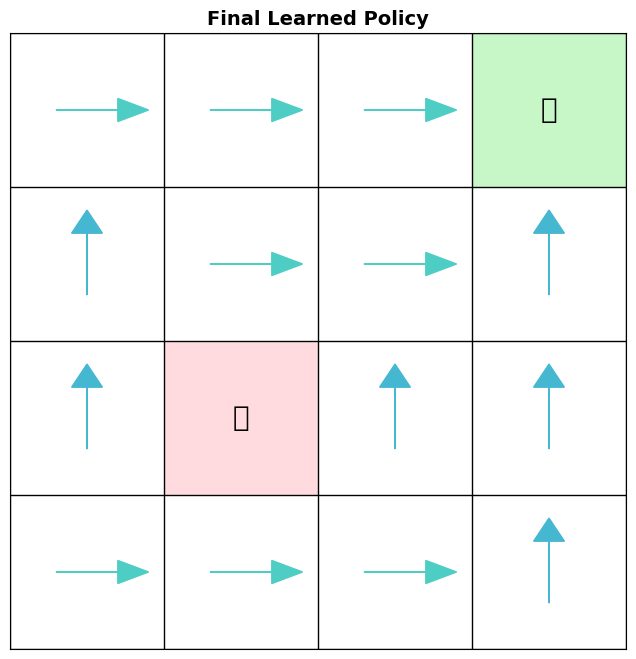


播放训练动画...


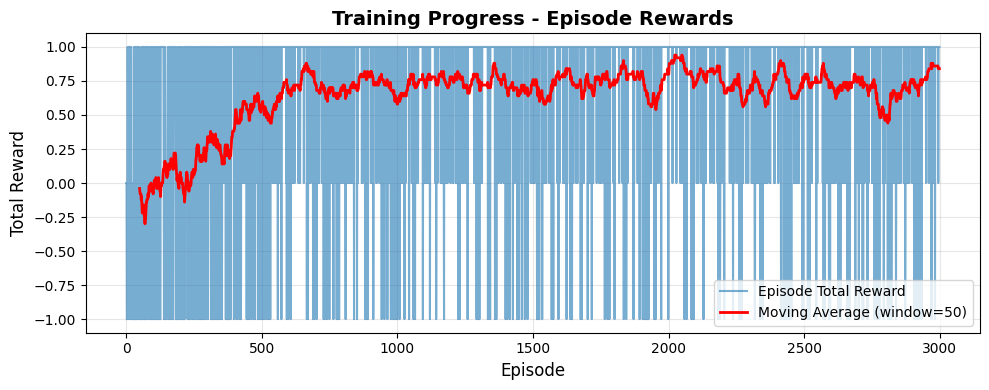


Q值分析


c:\Users\Lenovo\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


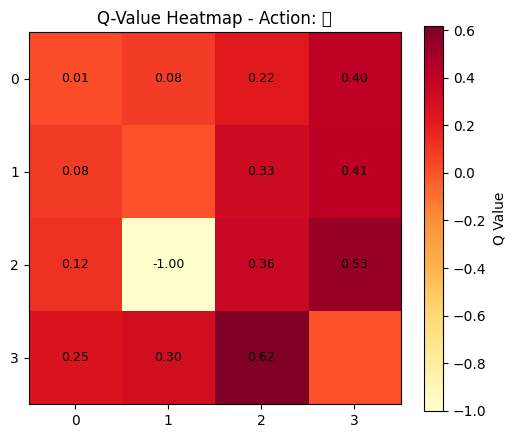

c:\Users\Lenovo\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


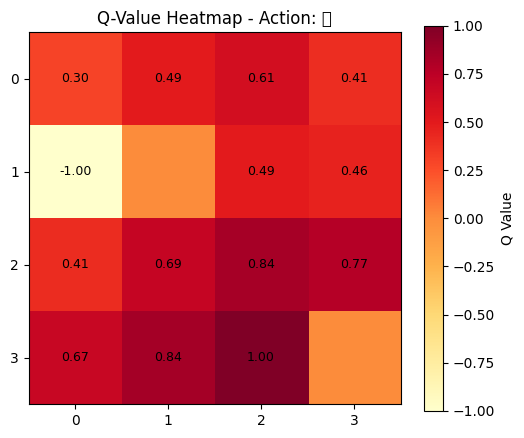

c:\Users\Lenovo\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


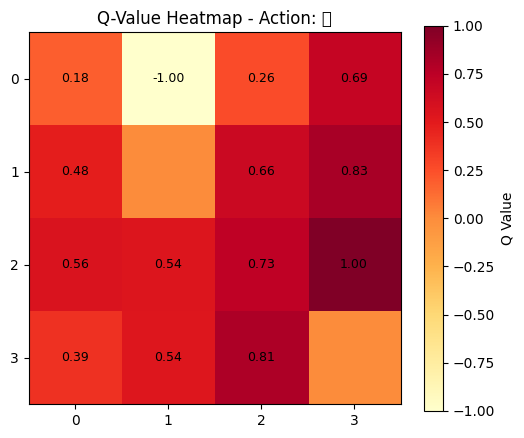

c:\Users\Lenovo\miniconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


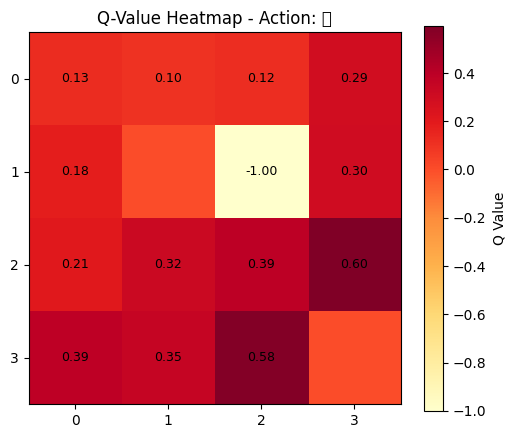

In [2]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import time

# ==================== 1. 环境设置 ====================
# 4x4 网格世界
ACTIONS = [0, 1, 2, 3]  # 0=上, 1=右, 2=下, 3=左
ACTION_SYMBOLS = ['↑', '→', '↓', '←']
ACTION_COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

gamma = 0.9  # 折扣因子

# 环境布局
GOAL_STATE = 15  # 目标位置（右下角）
TRAP_STATE = 5   # 陷阱位置（中间偏左）

def take_action(state, action):
    """执行动作，返回下一个状态和奖励"""
    if state == GOAL_STATE or state == TRAP_STATE:
        return state, 0
    
    row, col = divmod(state, 4)
    if action == 0: row = max(0, row-1)      # 上
    elif action == 1: col = min(3, col+1)    # 右
    elif action == 2: row = min(3, row+1)    # 下
    elif action == 3: col = max(0, col-1)    # 左
    
    next_state = row * 4 + col
    
    # 奖励逻辑
    if next_state == GOAL_STATE:
        reward = 1
    elif next_state == TRAP_STATE:
        reward = -1
    else:
        reward = 0
        
    return next_state, reward

# ==================== 2. MC Exploring Starts 核心算法 ====================
def mc_exploring_starts(episodes=5000, track_history=True):
    """MC Exploring Starts算法，可选是否追踪历史"""
    Q = defaultdict(lambda: np.zeros(len(ACTIONS)))
    returns = defaultdict(list)
    
    # 用于可视化
    history = [] if track_history else None
    episode_rewards = [] if track_history else None
    optimal_policy_history = [] if track_history else None
    
    for episode_idx in range(episodes):
        # --- Exploring Start: 随机选择起点状态和动作 ---
        start_state = np.random.randint(0, 16)
        start_action = np.random.choice(ACTIONS)
        
        # --- 生成完整的 Episode ---
        episode = []
        state = start_state
        action = start_action
        
        # 第一步
        next_state, reward = take_action(state, action)
        episode.append((state, action, reward))
        state = next_state
        
        # 继续生成轨迹（使用epsilon-greedy策略）
        total_reward = reward
        steps = 1
        
        while state not in [GOAL_STATE, TRAP_STATE] and steps < 100:  # 限制最大步数
            # epsilon-greedy策略，epsilon逐渐减小
            epsilon = max(0.1, 1.0 - episode_idx / 1000)
            if np.random.rand() < epsilon:
                act = np.random.choice(ACTIONS)
            else:
                act = np.argmax(Q[state])
            
            next_s, rew = take_action(state, act)
            episode.append((state, act, rew))
            total_reward += rew
            state = next_s
            steps += 1
        
        # 记录每episode的总奖励
        if track_history:
            episode_rewards.append(total_reward)
        
        # --- 计算 Return 并更新 Q 表 ---
        G = 0
        for t in range(len(episode)-1, -1, -1):
            state_t, action_t, reward_t = episode[t]
            G = gamma * G + reward_t
            
            returns[(state_t, action_t)].append(G)
            Q[state_t][action_t] = np.mean(returns[(state_t, action_t)])
        
        # 每500个episode记录一次策略
        if track_history and (episode_idx + 1) % 500 == 0:
            policy = get_policy(Q)
            optimal_policy_history.append(policy.copy())
            history.append((episode_idx + 1, Q.copy()))
    
    if track_history:
        return Q, history, episode_rewards, optimal_policy_history
    return Q

def get_policy(Q):
    """从Q表中提取最优策略"""
    policy = {}
    for state in range(16):
        if state == GOAL_STATE:
            policy[state] = 'G'
        elif state == TRAP_STATE:
            policy[state] = 'H'
        else:
            best_action = np.argmax(Q[state])
            policy[state] = ACTION_SYMBOLS[best_action]
    return policy

# ==================== 3. 可视化功能 ====================
class GridWorldVisualizer:
    """网格世界可视化器"""
    
    def __init__(self, Q=None):
        self.fig, self.ax = plt.subplots(figsize=(10, 8))
        self.Q = Q
        self.setup_grid()
        
    def setup_grid(self):
        """设置网格基础布局"""
        self.ax.clear()
        self.ax.set_xlim(-0.5, 3.5)
        self.ax.set_ylim(-0.5, 3.5)
        self.ax.set_aspect('equal')
        
        # 绘制网格线
        for i in range(5):
            self.ax.axhline(i - 0.5, color='black', linewidth=1)
            self.ax.axvline(i - 0.5, color='black', linewidth=1)
        
        # 标记特殊格子
        for state in range(16):
            row, col = divmod(state, 4)
            if state == GOAL_STATE:
                rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, 
                                        facecolor='#90EE90', alpha=0.5)
                self.ax.add_patch(rect)
                self.ax.text(col, row, '🎯', ha='center', va='center', fontsize=20)
            elif state == TRAP_STATE:
                rect = patches.Rectangle((col-0.5, row-0.5), 1, 1, 
                                        facecolor='#FFB6C1', alpha=0.5)
                self.ax.add_patch(rect)
                self.ax.text(col, row, '💀', ha='center', va='center', fontsize=20)
        
        self.ax.set_xticks([])
        self.ax.set_yticks([])
        self.ax.set_title("Monte Carlo Exploring Starts - Grid World", fontsize=14, fontweight='bold')
        
    def draw_policy(self, policy):
        """绘制策略箭头"""
        for state in range(16):
            if state in [GOAL_STATE, TRAP_STATE]:
                continue
            
            row, col = divmod(state, 4)
            action_symbol = policy[state]
            
            # 根据动作绘制不同颜色的箭头
            if action_symbol == '↑':
                self.ax.arrow(col, row+0.2, 0, -0.4, head_width=0.2, 
                             head_length=0.15, fc=ACTION_COLORS[0], ec=ACTION_COLORS[0])
            elif action_symbol == '→':
                self.ax.arrow(col-0.2, row, 0.4, 0, head_width=0.15, 
                             head_length=0.2, fc=ACTION_COLORS[1], ec=ACTION_COLORS[1])
            elif action_symbol == '↓':
                self.ax.arrow(col, row-0.2, 0, 0.4, head_width=0.2, 
                             head_length=0.15, fc=ACTION_COLORS[2], ec=ACTION_COLORS[2])
            elif action_symbol == '←':
                self.ax.arrow(col+0.2, row, -0.4, 0, head_width=0.15, 
                             head_length=0.2, fc=ACTION_COLORS[3], ec=ACTION_COLORS[3])
    
    def draw_q_values(self, Q):
        """显示Q值（可选）"""
        for state in range(16):
            if state in [GOAL_STATE, TRAP_STATE]:
                continue
            
            row, col = divmod(state, 4)
            q_values = Q[state]
            
            # 在四个角显示小字Q值
            offset = 0.35
            self.ax.text(col-offset, row+offset, f'{q_values[0]:.2f}', 
                        fontsize=8, ha='center', va='center', color='red')
            self.ax.text(col+offset, row+offset, f'{q_values[1]:.2f}', 
                        fontsize=8, ha='center', va='center', color='blue')
            self.ax.text(col+offset, row-offset, f'{q_values[2]:.2f}', 
                        fontsize=8, ha='center', va='center', color='green')
            self.ax.text(col-offset, row-offset, f'{q_values[3]:.2f}', 
                        fontsize=8, ha='center', va='center', color='purple')
    
    def animate_training(self, history, episode_rewards, interval=200):
        """动画演示训练过程"""
        policy_history = []
        for episode, Q in history:
            policy = get_policy(Q)
            policy_history.append(policy)
        
        def update(frame):
            self.setup_grid()
            if frame < len(policy_history):
                self.draw_policy(policy_history[frame])
                title = f"Episode {history[frame][0]}"
                self.ax.set_title(title, fontsize=14, fontweight='bold')
            return self.ax,
        
        # 显示奖励曲线
        fig2, ax2 = plt.subplots(figsize=(10, 4))
        ax2.plot(episode_rewards, alpha=0.6, label='Episode Total Reward')
        # 添加移动平均
        window = 50
        if len(episode_rewards) >= window:
            moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
            ax2.plot(range(window-1, len(episode_rewards)), moving_avg, 
                    'r-', linewidth=2, label=f'Moving Average (window={window})')
        
        ax2.set_xlabel('Episode', fontsize=12)
        ax2.set_ylabel('Total Reward', fontsize=12)
        ax2.set_title('Training Progress - Episode Rewards', fontsize=14, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        anim = FuncAnimation(self.fig, update, frames=len(policy_history), 
                           interval=interval, repeat=False)
        plt.tight_layout()
        plt.show()
        return anim

def test_policy(Q, num_tests=10):
    """测试学习到的策略"""
    print("\n" + "="*50)
    print("策略测试")
    print("="*50)
    
    success_count = 0
    total_steps = 0
    
    for test in range(num_tests):
        # 从随机非特殊状态开始
        possible_states = [s for s in range(16) if s not in [GOAL_STATE, TRAP_STATE]]
        state = np.random.choice(possible_states)
        start_state = state
        steps = 0
        
        print(f"\n测试 {test+1}: 从状态 {state} ({state//4},{state%4}) 出发")
        
        while state not in [GOAL_STATE, TRAP_STATE] and steps < 50:
            action = np.argmax(Q[state])
            action_symbol = ACTION_SYMBOLS[action]
            next_state, reward = take_action(state, action)
            
            print(f"  步骤 {steps+1}: 状态 {state} → {action_symbol} → 状态 {next_state} (奖励: {reward})")
            
            state = next_state
            steps += 1
        
        if state == GOAL_STATE:
            success_count += 1
            total_steps += steps
            print(f"  ✅ 成功到达目标！用了 {steps} 步")
        else:
            print(f"  ❌ 掉入陷阱或超过步数限制")
    
    if success_count > 0:
        print(f"\n结果: {success_count}/{num_tests} 次成功到达目标")
        print(f"平均步数: {total_steps/success_count:.1f}")
    else:
        print("\n结果: 没有成功到达目标")

# ==================== 4. 主程序 ====================
if __name__ == "__main__":
    print("开始训练 MC Exploring Starts...")
    print("训练中，请稍候...")
    
    # 训练算法
    Q, history, episode_rewards, policy_history = mc_exploring_starts(episodes=3000, track_history=True)
    
    # 显示最终策略
    final_policy = get_policy(Q)
    print("\n" + "="*50)
    print("最终学习到的策略:")
    print("="*50)
    for state in range(16):
        row, col = divmod(state, 4)
        if state == GOAL_STATE:
            print("  🎯 ", end=" ")
        elif state == TRAP_STATE:
            print("  💀 ", end=" ")
        else:
            print(f"  {final_policy[state]} ", end=" ")
        
        if col == 3:
            print()  # 换行
    
    # 测试策略
    test_policy(Q, num_tests=5)
    
    # 可视化
    print("\n" + "="*50)
    print("启动可视化...")
    print("="*50)
    
    visualizer = GridWorldVisualizer(Q)
    
    # 显示最终策略图
    visualizer.setup_grid()
    visualizer.draw_policy(final_policy)
    visualizer.ax.set_title("Final Learned Policy", fontsize=14, fontweight='bold')
    plt.show()
    
    # 动画演示训练过程
    print("\n播放训练动画...")
    anim = visualizer.animate_training(history, episode_rewards, interval=200)
    
    # 可选：显示Q值热力图
    print("\n" + "="*50)
    print("Q值分析")
    print("="*50)
    for action_idx, action_name in enumerate(['上', '右', '下', '左']):
        q_matrix = np.zeros((4, 4))
        for state in range(16):
            if state in [GOAL_STATE, TRAP_STATE]:
                continue
            row, col = divmod(state, 4)
            q_matrix[row, col] = Q[state][action_idx]
        
        plt.figure(figsize=(6, 5))
        plt.imshow(q_matrix, cmap='YlOrRd', interpolation='nearest')
        plt.colorbar(label='Q Value')
        plt.title(f'Q-Value Heatmap - Action: {action_name}')
        plt.xticks(range(4))
        plt.yticks(range(4))
        
        # 标注数值
        for i in range(4):
            for j in range(4):
                if q_matrix[i, j] != 0:
                    plt.text(j, i, f'{q_matrix[i, j]:.2f}', 
                            ha='center', va='center', color='black', fontsize=9)
        plt.show()